# Additional imports

In [1]:
import torch
import numpy as np

## Imports from the utility scripts

In [2]:
!pip install torchinfo
import torchinfo
import matplotlib.pyplot as plt

In [3]:
from training import load_checkpoint, mean_and_std_for_normalization
from fine_tuning import reset_head_last_fc
from model import PseudoAlexNet, DEVICE

from gpu_utils import clean_all_gpu_memory

from screen_images import CustomEnricoDataset, get_allowed_classes, make_screen_base_transform
from natural_images import make_caltech_base_transform, stratified_three_way_split, AugmentationWrapper

In [4]:
from maximization_core_logic import (
    FilterVisualizer,
    get_tensor_grid
)

from maximization_analysis import (
    analyze_all_pairs_drift,
    analyze_layer_filters,
    plot_fourier_cmap_grid,
    plot_fourier_angular_distribution_grid,
    plot_fourier_angular_difference_grid
)


In [5]:
from grad_cam import (
    plot_random_gradcam_edges,
    get_one_sample_per_class
)

from analysis_statistics import (
    plot_all_cka_pairs,
    plot_layer_weight_diagnostic
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 63.5 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=a0aef85a1ea87b3c5546e6816d0acaae589296e78f06ae5c29230462c3588a42
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [6]:
import os

def resolve_ckpt(name: str) -> str:
    candidates = [
        f"/kaggle/input/20-checkpoint-batchnorm/{name}",
        f"/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm/{name}",
        f"/kaggle/input/20-checkpoint-batchnorm/20-checkpoint-batchnorm/{name}",
        f"/kaggle/working/{name}",
        f"./{name}"
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return candidates[0]

CHECKPOINTS_NAT_IMAGES_PATH = resolve_ckpt("finished_nat_images.pth")
CHECKPOINTS_FT_FINISHED_PATH = resolve_ckpt("finished_drift_2.pth")
CHECKPOINTS_SCREEN_PATH = resolve_ckpt("finished_screen.pth")
ENRICO_CLASSES = len(get_allowed_classes())

# Activation Maximization Configuration
MAXIMIZATION_ITERATIONS = 200


# Analysis through per-filter random noise maximization

https://keras.io/examples/vision/visualizing_what_convnets_learn/

## Analyzing the natural images filters

2. Preloading weights of the peak natural images training

In [7]:
model = PseudoAlexNet(tiny_factor=1, p=0)
load_checkpoint(model=model, optimizer=None, path=CHECKPOINTS_NAT_IMAGES_PATH, device=DEVICE)
model = model.to(DEVICE)

🔄 Checkpoint loaded. Status: <All keys matched successfully>
Resuming from Epoch 42 | Loss: 2.1803


3. Creating the FilterVisualizer pattern according to (https://keras.io/examples/vision/visualizing_what_convnets_learn/). Activation Maximization (Feature Visualization)

In [8]:
visualizer_1 = FilterVisualizer(model, layer_num=0)
patterns_nat_images_layer_1 = visualizer_1.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_2 = FilterVisualizer(model, layer_num=1)
patterns_nat_images_layer_2 = visualizer_2.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_3 = FilterVisualizer(model, layer_num=3)
patterns_nat_images_layer_3 = visualizer_3.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_4 = FilterVisualizer(model, layer_num=4)
patterns_nat_images_layer_4 = visualizer_4.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

4. Visualizations for the filter of the two last convolutional layers which were made trainable.

In [9]:
nat_images_layer_1_output = get_tensor_grid(list(patterns_nat_images_layer_1.values()))
plt.imsave("nat_images_layer_1_maximization.png", nat_images_layer_1_output)

nat_images_layer_2_output = get_tensor_grid(list(patterns_nat_images_layer_2.values()))
plt.imsave("nat_images_layer_2_maximization.png", nat_images_layer_2_output)

nat_images_layer_3_output = get_tensor_grid(list(patterns_nat_images_layer_3.values()))
plt.imsave("nat_images_layer_3_maximization.png", nat_images_layer_3_output)

nat_images_layer_4_output = get_tensor_grid(list(patterns_nat_images_layer_4.values()))
plt.imsave("nat_images_layer_4_maximization.png", nat_images_layer_4_output)

clean_all_gpu_memory()

✅ Cleared VRAM for GPU 0: Tesla T4
✅ Cleared VRAM for GPU 1: Tesla T4


## Analyzing the fine-tuned model after the digital screens training

### After the drift stage

1. Loading the weights after the drift.

In [10]:
model = PseudoAlexNet(tiny_factor=1, p=0)
reset_head_last_fc(model, output_features=ENRICO_CLASSES)
load_checkpoint(model=model, optimizer=None, path=CHECKPOINTS_FT_FINISHED_PATH, device=DEVICE)
model = model.to(DEVICE)

🔄 Checkpoint loaded. Status: <All keys matched successfully>
Resuming from Epoch 30 | Loss: 1.7179


2. Visualizing the filters

In [11]:
visualizer_ft_1 = FilterVisualizer(model, layer_num=0)
patterns_images_drift_finished_layer_1 = visualizer_ft_1.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_ft_2 = FilterVisualizer(model, layer_num=1)
patterns_images_drift_finished_layer_2 = visualizer_ft_2.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_ft_3 = FilterVisualizer(model, layer_num=3)
patterns_images_drift_finished_layer_3 = visualizer_ft_3.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_ft_4 = FilterVisualizer(model, layer_num=4)
patterns_images_drift_finished_layer_4 = visualizer_ft_4.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

In [12]:
drift_finished_layer_1_output = get_tensor_grid(list(patterns_images_drift_finished_layer_1.values()))
plt.imsave("drift_finished_layer_1_maximization.png", drift_finished_layer_1_output)

drift_finished_layer_2_output = get_tensor_grid(list(patterns_images_drift_finished_layer_2.values()))
plt.imsave("drift_finished_layer_2_maximization.png", drift_finished_layer_2_output)

drift_finished_layer_3_output = get_tensor_grid(list(patterns_images_drift_finished_layer_3.values()))
plt.imsave("drift_finished_layer_3_maximization.png", drift_finished_layer_3_output)

drift_finished_layer_4_output = get_tensor_grid(list(patterns_images_drift_finished_layer_4.values()))
plt.imsave("drift_finished_layer_4_maximization.png", drift_finished_layer_4_output)

## Analyzing the purely screen trained model

1. Loading the weights after the screen training

In [13]:
model = PseudoAlexNet(tiny_factor=1, p=0)
reset_head_last_fc(model, output_features=ENRICO_CLASSES)
load_checkpoint(model=model, optimizer=None, path=CHECKPOINTS_SCREEN_PATH, device=DEVICE)
model = model.to(DEVICE)

🔄 Checkpoint loaded. Status: <All keys matched successfully>
Resuming from Epoch 25 | Loss: 1.9430


2. Visualizing the weights

In [14]:
visualizer_sc_1 = FilterVisualizer(model, layer_num=0)
patterns_screen_layer_1 = visualizer_sc_1.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_sc_2 = FilterVisualizer(model, layer_num=1)
patterns_screen_layer_2 = visualizer_sc_2.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_sc_3 = FilterVisualizer(model, layer_num=3)
patterns_screen_layer_3 = visualizer_sc_3.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

visualizer_sc_4 = FilterVisualizer(model, layer_num=4)
patterns_screen_layer_4 = visualizer_sc_4.visualize(filter_indices=None, iterations=MAXIMIZATION_ITERATIONS)

In [15]:
screen_layer_1_output = get_tensor_grid(list(patterns_screen_layer_1.values()))
plt.imsave("screen_layer_1_maximization.png", screen_layer_1_output)

screen_layer_2_output = get_tensor_grid(list(patterns_screen_layer_2.values()))
plt.imsave("screen_layer_2_maximization.png", screen_layer_2_output)

screen_layer_3_output = get_tensor_grid(list(patterns_screen_layer_3.values()))
plt.imsave("screen_layer_3_maximization.png", screen_layer_3_output)

screen_layer_4_output = get_tensor_grid(list(patterns_screen_layer_4.values()))
plt.imsave("screen_layer_4_maximization.png", screen_layer_4_output)

## Statistical Analysis with abs diff masks, SIMM, mae, mse

In [16]:
l1_pairwise_data = analyze_all_pairs_drift(
    nat_patterns=patterns_nat_images_layer_1,
    ft_patterns=patterns_images_drift_finished_layer_1,
    scr_patterns=patterns_screen_layer_1,
    layer_name="features.0.conv"
)

l2_pairwise_data = analyze_all_pairs_drift(
    nat_patterns=patterns_nat_images_layer_2,
    ft_patterns=patterns_images_drift_finished_layer_2,
    scr_patterns=patterns_screen_layer_2,
    layer_name="features.1.conv"
)

l3_pairwise_data = analyze_all_pairs_drift(
    nat_patterns=patterns_nat_images_layer_3,
    ft_patterns=patterns_images_drift_finished_layer_3,
    scr_patterns=patterns_screen_layer_3,
    layer_name="features.3.conv"
)

l4_pairwise_data = analyze_all_pairs_drift(
    nat_patterns=patterns_nat_images_layer_4,
    ft_patterns=patterns_images_drift_finished_layer_4,
    scr_patterns=patterns_screen_layer_4,
    layer_name="features.4.conv"
)


>>> EXECUTING THREE-WAY PAIRWISE STRUCTURAL RUN FOR: FEATURES.0.CONV <<<

======== STATISTICAL DRIFT ANALYSIS FOR FEATURES.0.CONV (Fine-Tuned - Natural) ========
Total Filters Evaluated : 12
Layer Average SSIM      : 0.7341
Layer Average Total MAE : 0.028754
  └─ Appeared Gain MAE  : 0.014388  (ReLU(Fine-Tuned - Natural))
  └─ Disappeared Loss MAE: 0.014367 (ReLU(Natural - Fine-Tuned))
Layer Average MSE       : 0.002247
Most Drifted Filter     : Index 8 (SSIM: 0.2025)
Least Drifted Filter    : Index 6 (SSIM: 1.0000)

======== STATISTICAL DRIFT ANALYSIS FOR FEATURES.0.CONV (Scratch - Natural) ========
Total Filters Evaluated : 12
Layer Average SSIM      : 0.2015
Layer Average Total MAE : 0.071231
  └─ Appeared Gain MAE  : 0.034411  (ReLU(Scratch - Natural))
  └─ Disappeared Loss MAE: 0.036820 (ReLU(Natural - Scratch))
Layer Average MSE       : 0.007719
Most Drifted Filter     : Index 2 (SSIM: -0.2859)
Least Drifted Filter    : Index 6 (SSIM: 0.5282)

======== STATISTICAL DRIFT ANALYSIS

## Running Fourier Analysis on all of the visualization maximization images

### 1. Preparing the data

In [17]:
filter_data = {
    'natural': {
        '0': list(patterns_nat_images_layer_1.values()),
        '1': list(patterns_nat_images_layer_2.values()),
        '3': list(patterns_nat_images_layer_3.values()),
        '4': list(patterns_nat_images_layer_4.values())
    },
    'fine-tuned': {
        '0': list(patterns_images_drift_finished_layer_1.values()),
        '1': list(patterns_images_drift_finished_layer_2.values()),
        '3': list(patterns_images_drift_finished_layer_3.values()),
        '4': list(patterns_images_drift_finished_layer_4.values()) 
    },
    'screen': {
        '0': list(patterns_screen_layer_1.values()),
        '1': list(patterns_screen_layer_2.values()),
        '3': list(patterns_screen_layer_3.values()),
        '4': list(patterns_screen_layer_4.values()) 
    }
}

models = ['natural', 'fine-tuned', 'screen']
layers = ['0', '1', '3', '4']

print("Data pipeline channels initialized successfully.")

Data pipeline channels initialized successfully.


### 2. Plotting and analyzing


📊 1D ANGULAR ENERGY DISTRIBUTION SUBPLOT LEGEND MAPPING:
SUBPLOT   | MODEL          | LAYER                  | ANISOTROPY INDEX (NDI)
----------------------------------------------------------------------------
(a)      | NATURAL        | FEATURES.0.CONV        | 0.1434
(b)      | NATURAL        | FEATURES.1.CONV        | 0.1339
(c)      | NATURAL        | FEATURES.3.CONV        | 0.0433
(d)      | NATURAL        | FEATURES.4.CONV        | 0.0646
(e)      | FINE-TUNED     | FEATURES.0.CONV        | 0.1160
(f)      | FINE-TUNED     | FEATURES.1.CONV        | 0.1276
(g)      | FINE-TUNED     | FEATURES.3.CONV        | 0.0524
(h)      | FINE-TUNED     | FEATURES.4.CONV        | 0.0663
(i)      | SCREEN         | FEATURES.0.CONV        | 0.1402
(j)      | SCREEN         | FEATURES.1.CONV        | 0.0355
(k)      | SCREEN         | FEATURES.3.CONV        | -0.0210
(l)      | SCREEN         | FEATURES.4.CONV        | -0.0492



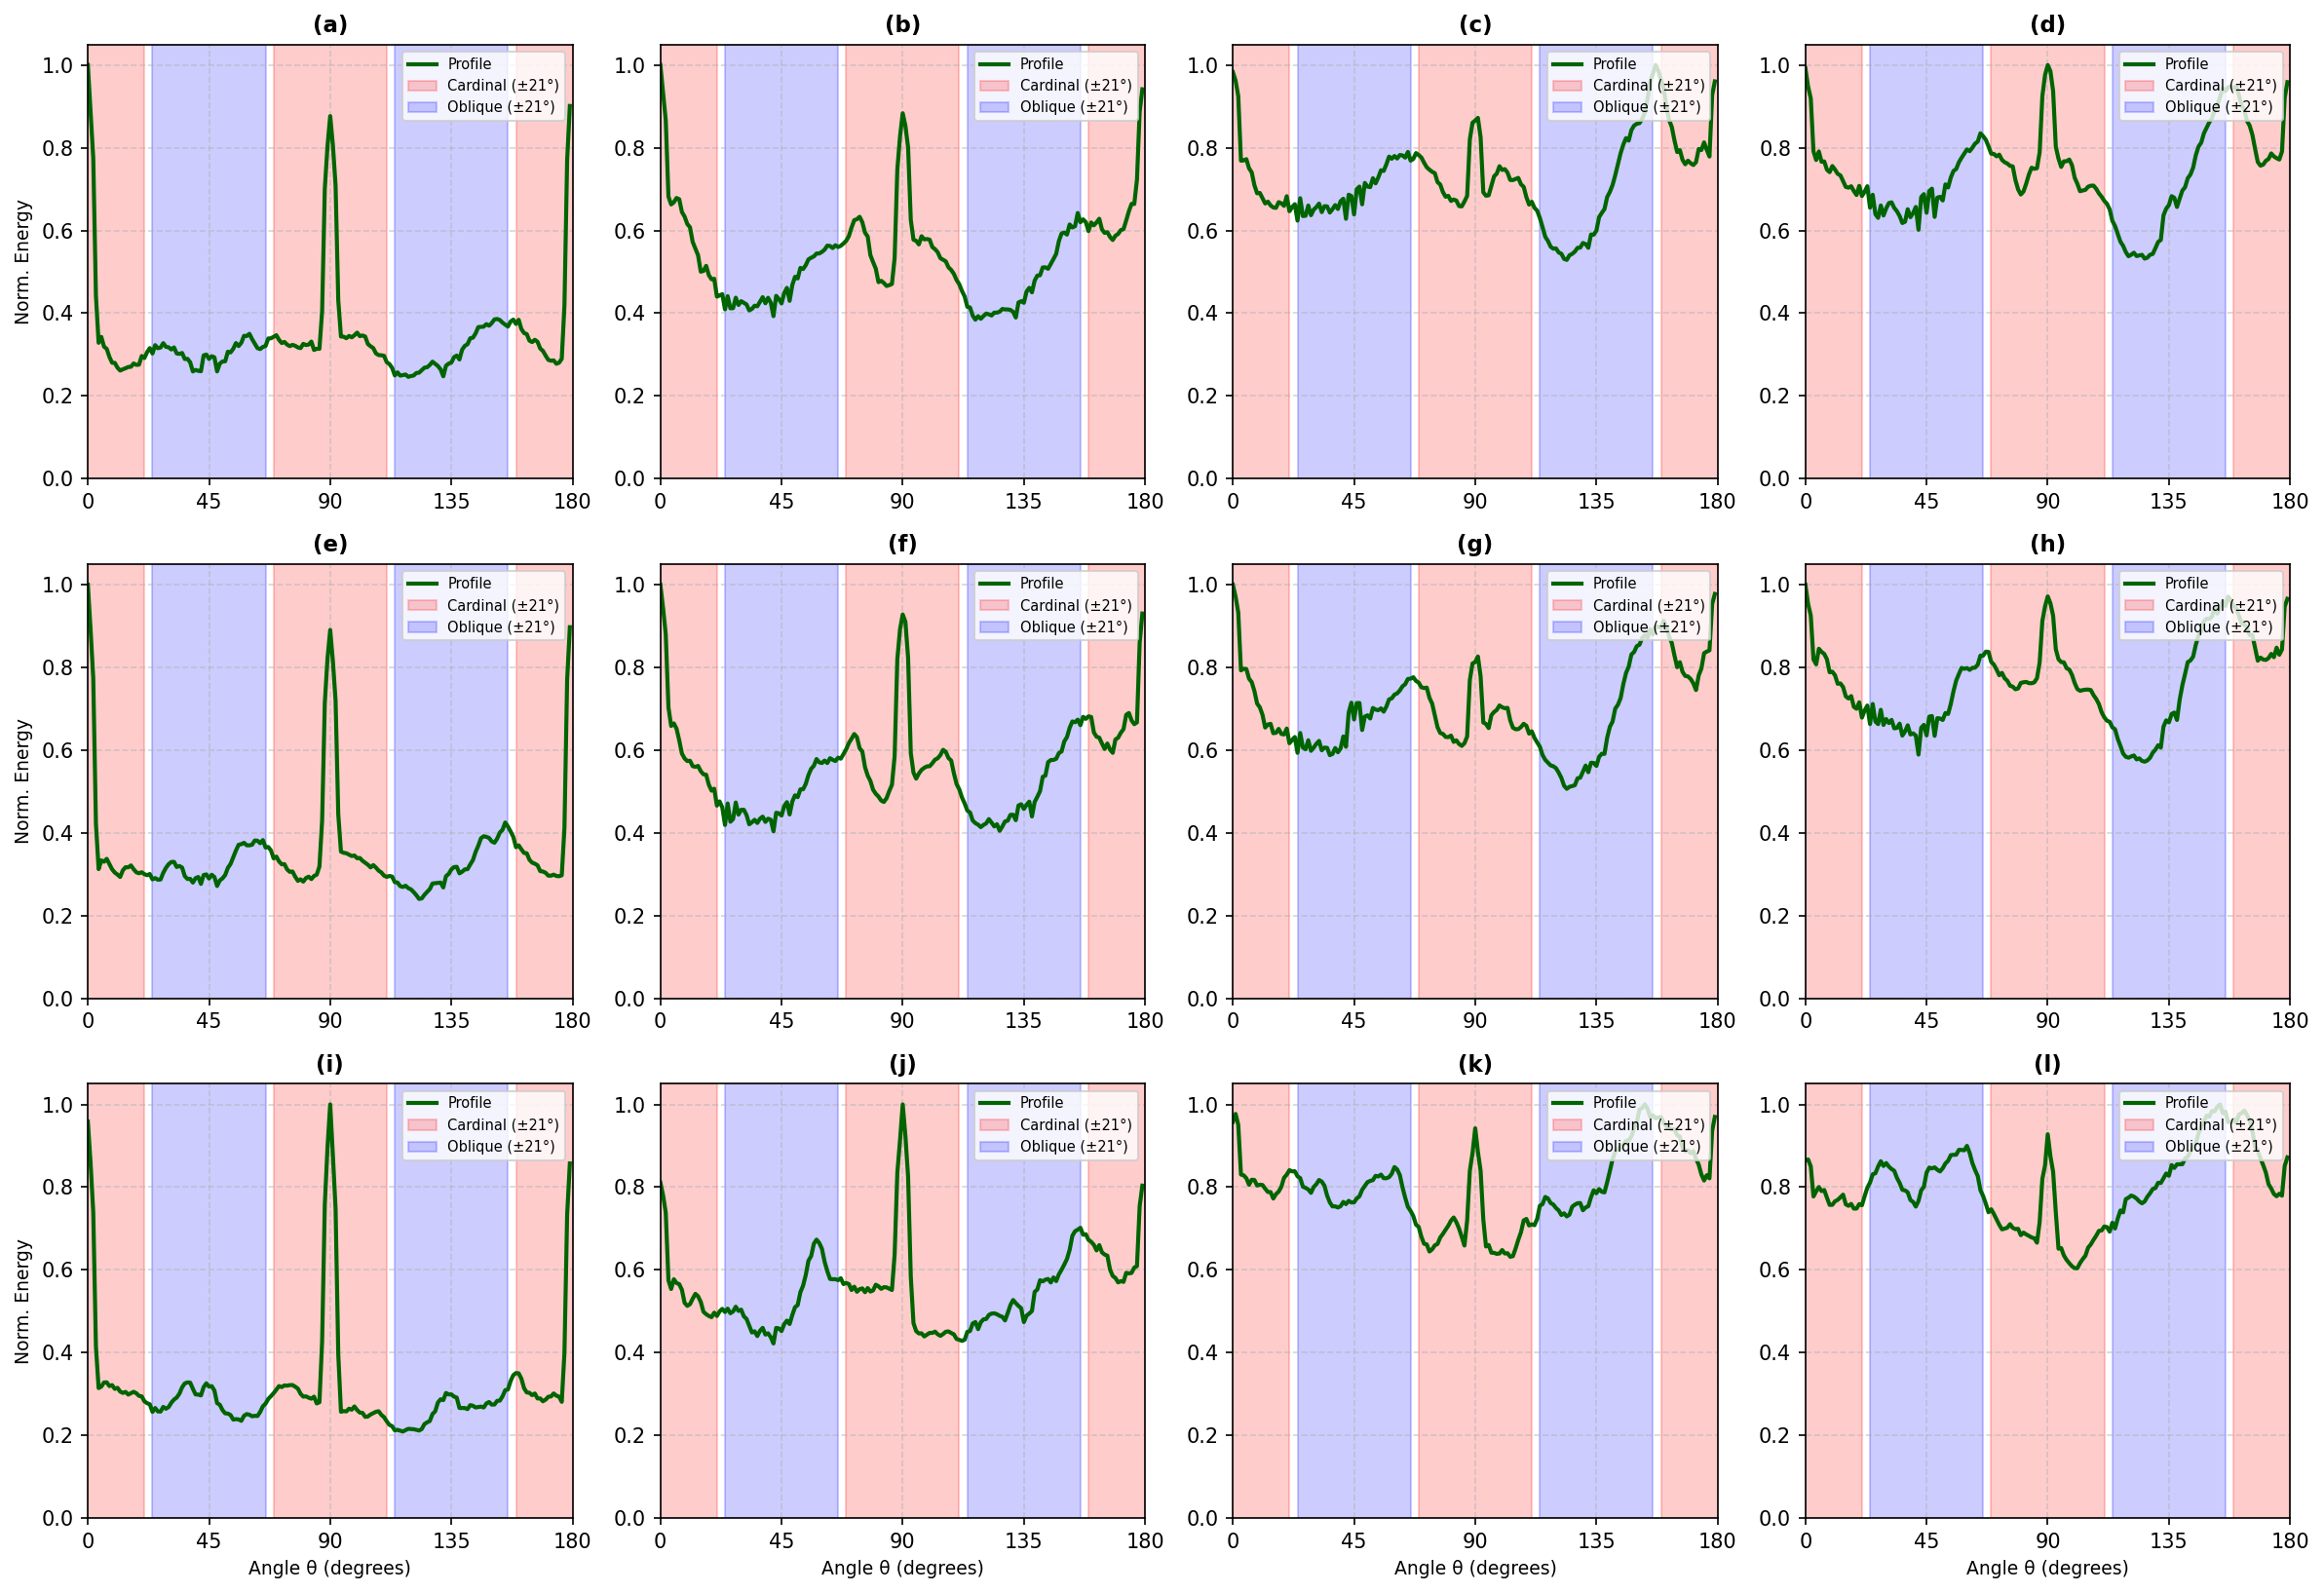


📊 1D ANGULAR ENERGY DIFFERENCE PROFILES SUBPLOT LEGEND MAPPING:
SUBPLOT   | SUBTRACTION PAIR (B - A)       | LAYER              | Δ NDI (B-A) 
-------------------------------------------------------------------------------------
(a)      | FINE-TUNED - NATURAL           | FEATURES.0.CONV |    -0.0275
(b)      | FINE-TUNED - NATURAL           | FEATURES.1.CONV |    -0.0063
(c)      | FINE-TUNED - NATURAL           | FEATURES.3.CONV |    +0.0091
(d)      | FINE-TUNED - NATURAL           | FEATURES.4.CONV |    +0.0018
(e)      | SCREEN - NATURAL               | FEATURES.0.CONV |    -0.0033
(f)      | SCREEN - NATURAL               | FEATURES.1.CONV |    -0.0984
(g)      | SCREEN - NATURAL               | FEATURES.3.CONV |    -0.0643
(h)      | SCREEN - NATURAL               | FEATURES.4.CONV |    -0.1137



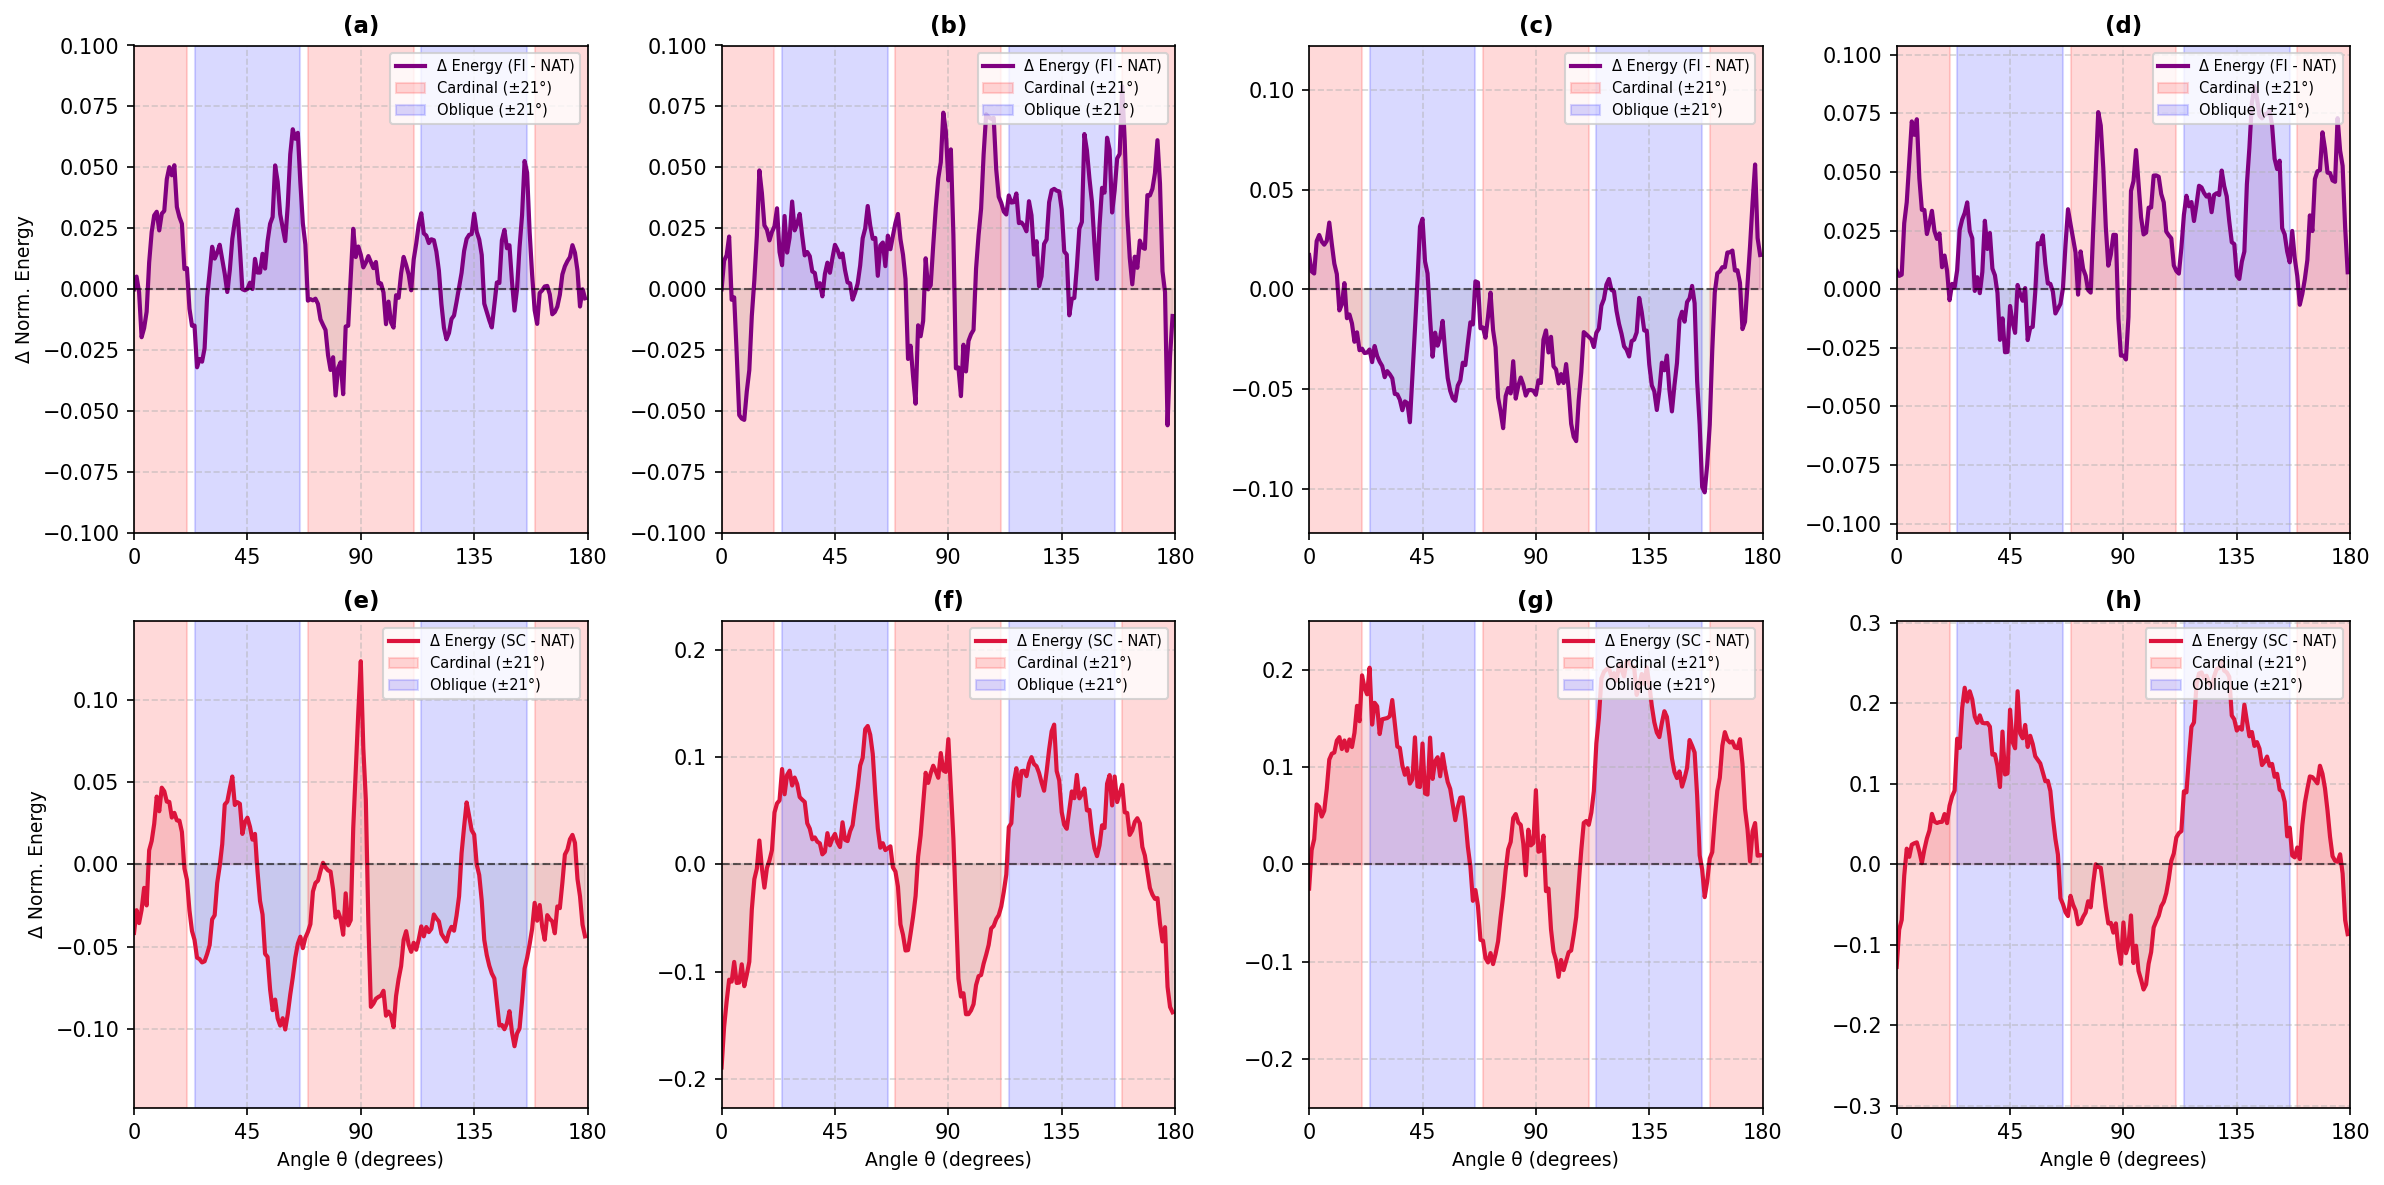

In [18]:
plot_fourier_angular_distribution_grid(filter_data, models, layers, plot_differences=True, use_log=False);


# GradCAM

https://github.com/jacobgil/pytorch-grad-cam

## Analyzing the natural images layer 3 and 4

### Data load

In [19]:
import torch.utils.data
from torchvision import datasets
from torchvision.transforms import v2

original_dataset = datasets.Caltech101(root='./data', download=True, transform=make_caltech_base_transform(resize=(300,200)))

100%|██████████| 137M/137M [00:03<00:00, 40.3MB/s]


### Weight load

In [20]:
import os

def resolve_ckpt(name: str) -> str:
    candidates = [
        f"/kaggle/input/20-checkpoint-batchnorm/{name}",
        f"/kaggle/input/datasets/nazariyyuchnovskiy/20-checkpoint-batchnorm/{name}",
        f"/kaggle/input/20-checkpoint-batchnorm/20-checkpoint-batchnorm/{name}",
        f"/kaggle/working/{name}",
        f"./{name}"
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return candidates[0]

CHECKPOINTS_NAT_IMAGES_PATH = resolve_ckpt("finished_nat_images_max_epochs.pth")
CHECKPOINTS_FT_FINISHED_PATH = resolve_ckpt("finished_drift_2_max_epochs.pth")
CHECKPOINTS_SCREEN_PATH = resolve_ckpt("finished_screen_max_epochs.pth")
ENRICO_CLASSES = len(get_allowed_classes())


Getting one sample per each class

In [21]:
categories_caltech_101 = original_dataset.categories
idx_to_class = {i: cat for i, cat in enumerate(categories_caltech_101)}

sps_caltech_101 = get_one_sample_per_class(dataset=original_dataset, idx_to_class=idx_to_class)

✅ Found class: Faces
✅ Found class: Faces_easy
✅ Found class: Leopards
✅ Found class: Motorbikes
✅ Found class: accordion
✅ Found class: airplanes
✅ Found class: anchor
✅ Found class: ant
✅ Found class: barrel
✅ Found class: bass
✅ Found class: beaver
✅ Found class: binocular
✅ Found class: bonsai
✅ Found class: brain
✅ Found class: brontosaurus
✅ Found class: buddha
✅ Found class: butterfly
✅ Found class: camera
✅ Found class: cannon
✅ Found class: car_side
✅ Found class: ceiling_fan
✅ Found class: cellphone
✅ Found class: chair
✅ Found class: chandelier
✅ Found class: cougar_body
✅ Found class: cougar_face
✅ Found class: crab
✅ Found class: crayfish
✅ Found class: crocodile
✅ Found class: crocodile_head
✅ Found class: cup
✅ Found class: dalmatian
✅ Found class: dollar_bill
✅ Found class: dolphin
✅ Found class: dragonfly
✅ Found class: electric_guitar
✅ Found class: elephant
✅ Found class: emu
✅ Found class: euphonium
✅ Found class: ewer
✅ Found class: ferry
✅ Found class: flamingo
✅ 

In [22]:
plot_random_gradcam_edges(
    model=model,
    target_layers=model.features[3].conv,  # Make sure to target the internal .conv layer!
    samples_dict=sps_caltech_101,         # Your dictionary of {target_idx: image_tensor}
    class_names=idx_to_class,             # Your mapping of index to class string
    num_samples=5,
    file_name="nat_image_layer_3"# How many random classes to plot
)

An exception occurred in CAM with block: <class 'IndexError'>. Message: index 59 is out of bounds for dimension 0 with size 11


In [23]:
plot_random_gradcam_edges(
    model=model,
    target_layers=model.features[4].conv,  # Make sure to target the internal .conv layer!
    samples_dict=sps_caltech_101,         # Your dictionary of {target_idx: image_tensor}
    class_names=idx_to_class,             # Your mapping of index to class string
    num_samples=5,
    file_name="nat_image_layer_4"
)

An exception occurred in CAM with block: <class 'IndexError'>. Message: index 59 is out of bounds for dimension 0 with size 11


In [24]:
plot_random_gradcam_edges(
    model=model,
    target_layers=[model.features[x].conv for x in range(3,5)],  # Make sure to target the internal .conv layer!
    samples_dict=sps_caltech_101,         # Your dictionary of {target_idx: image_tensor}
    class_names=idx_to_class,             # Your mapping of index to class string
    num_samples=5,
    file_name="nat_image_layer_3_and_4"
)

An exception occurred in CAM with block: <class 'IndexError'>. Message: index 59 is out of bounds for dimension 0 with size 11


## Analyzing the fine-tuned model after the digital screens training

Loading model

In [25]:
model = PseudoAlexNet(tiny_factor=1, p=0)
reset_head_last_fc(model, output_features=ENRICO_CLASSES)
load_checkpoint(model=model, optimizer=None, path=CHECKPOINTS_FT_FINISHED_PATH, device=DEVICE)
model = model.to(DEVICE)

⚠️ Path not found: /kaggle/input/20-checkpoint-batchnorm/finished_drift_2_max_epochs.pth


Loading the data

In [26]:
from torchvision.transforms import v2
import os

def resolve_enrico_root() -> str:
    candidates = [
        "/kaggle/input/enricoscreenshotsandwireframes",
        "/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
        "./data/enricoscreenshotsandwireframes"
    ]
    for c in candidates:
        if os.path.exists(c):
            return c
    return candidates[0]

ENRICO_ROOT = resolve_enrico_root()
screen_preprocess = make_screen_base_transform(resize=(300, 200))

screen_train_raw, _, _ = CustomEnricoDataset.create_splits(
    root=ENRICO_ROOT,
    val_size=0.15,
    test_size=0.15,
    use_wireframes=False,
    train_transform=screen_preprocess,
    eval_transform=screen_preprocess
)

screen_raw_loader = torch.utils.data.DataLoader(screen_train_raw, batch_size=64, shuffle=False, num_workers=3)
screen_train_mean, screen_train_std = mean_and_std_for_normalization(screen_raw_loader)

universal_base_screen = v2.Compose([
    screen_preprocess,
    v2.Normalize(mean=screen_train_mean, std=screen_train_std, inplace=False)
])

screen_dataset, _, _ = CustomEnricoDataset.create_splits(
    root=ENRICO_ROOT,
    val_size=0.15,
    test_size=0.15,
    use_wireframes=False,
    train_transform=universal_base_screen,
    eval_transform=universal_base_screen
)


In [27]:
class_to_idx = screen_dataset.class_to_idx
idx_to_class = dict(zip(class_to_idx.values(), class_to_idx.keys()))

sps_enrico = get_one_sample_per_class(dataset=screen_dataset, idx_to_class=idx_to_class)

✅ Found class: tutorial
✅ Found class: list
✅ Found class: modal
✅ Found class: gallery
✅ Found class: news
✅ Found class: bare
✅ Found class: form
✅ Found class: settings
✅ Found class: login
✅ Found class: menu
✅ Found class: terms


### Plotting the GradCAM analysis for Enrico

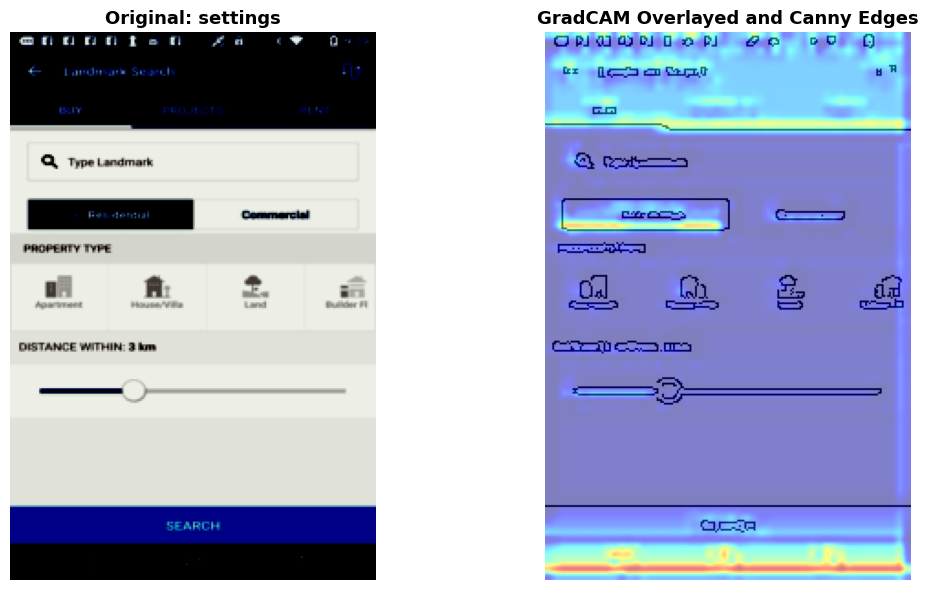

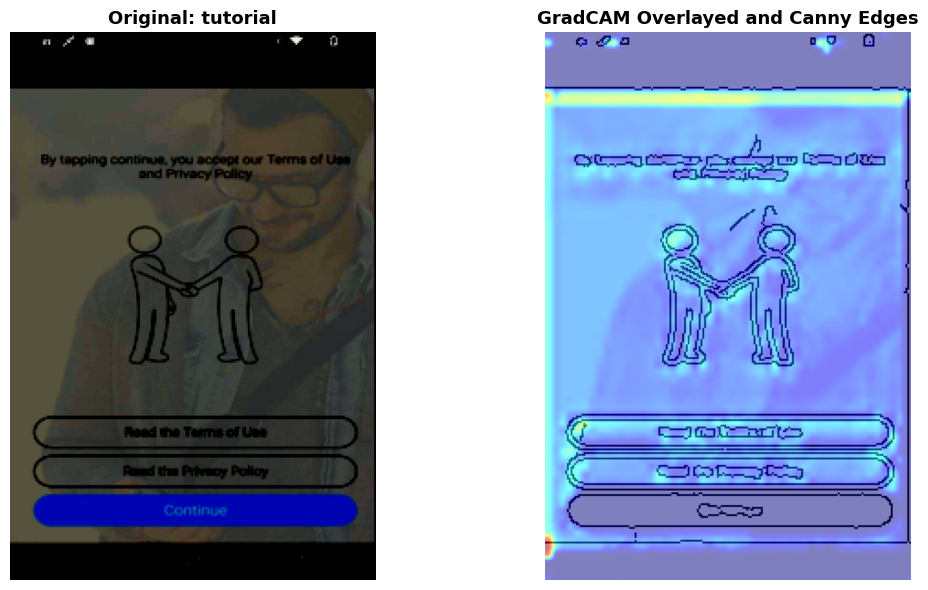

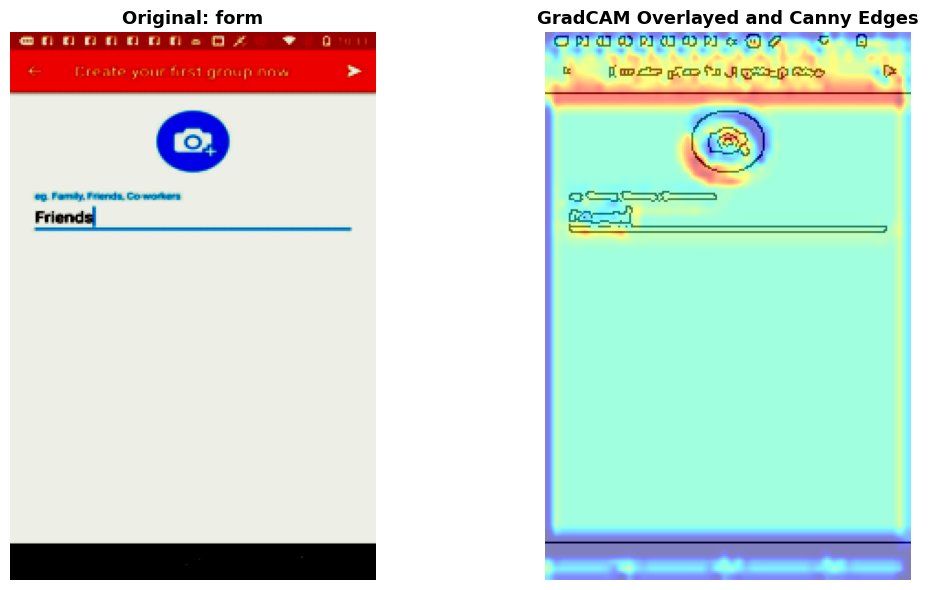

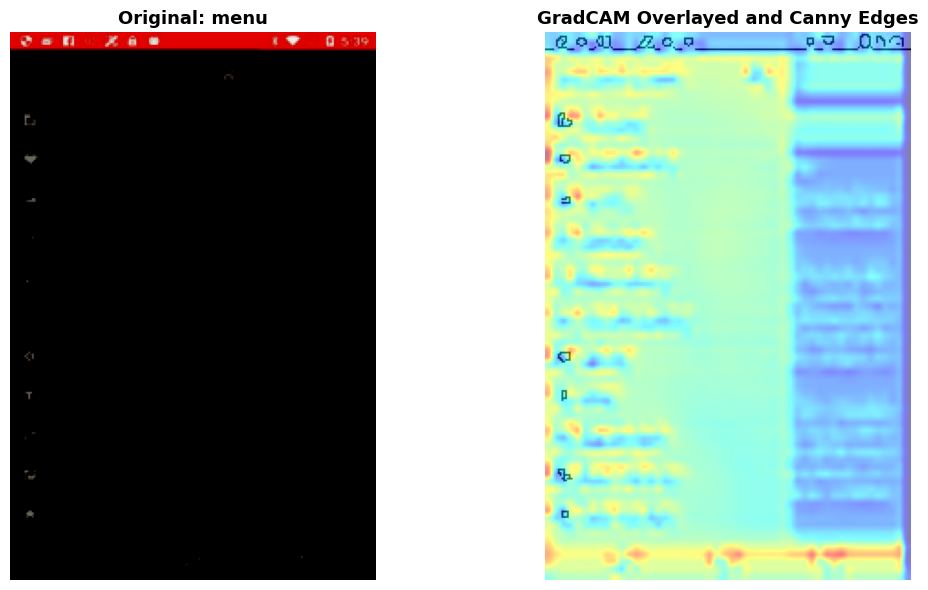

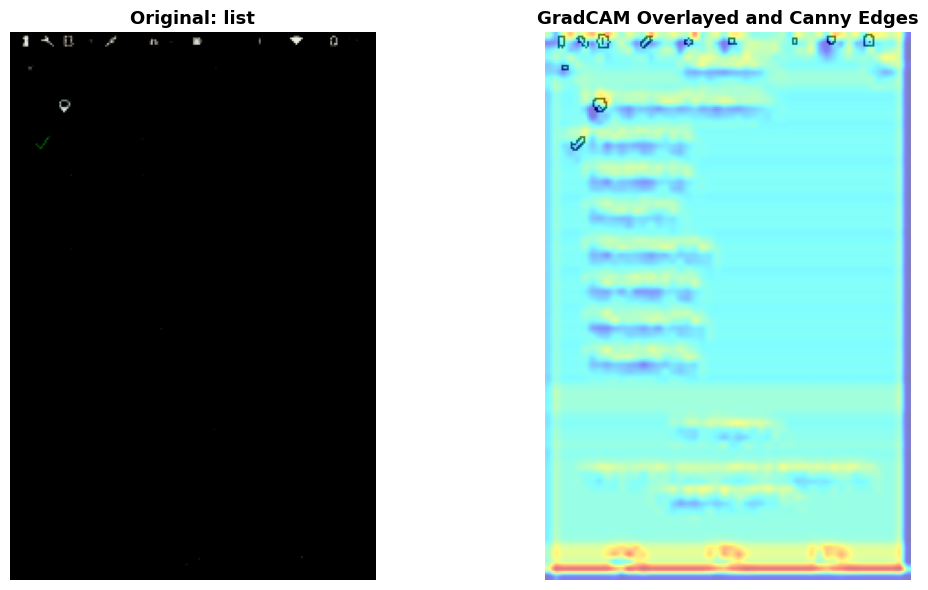

In [28]:
plot_random_gradcam_edges(
    model=model,
    target_layers=model.features[3].conv,  # Make sure to target the internal .conv layer!
    samples_dict=sps_enrico,         # Your dictionary of {target_idx: image_tensor}
    class_names=idx_to_class,             # Your mapping of index to class string
    num_samples=5,
    file_name="screen_image_3_layer"
)

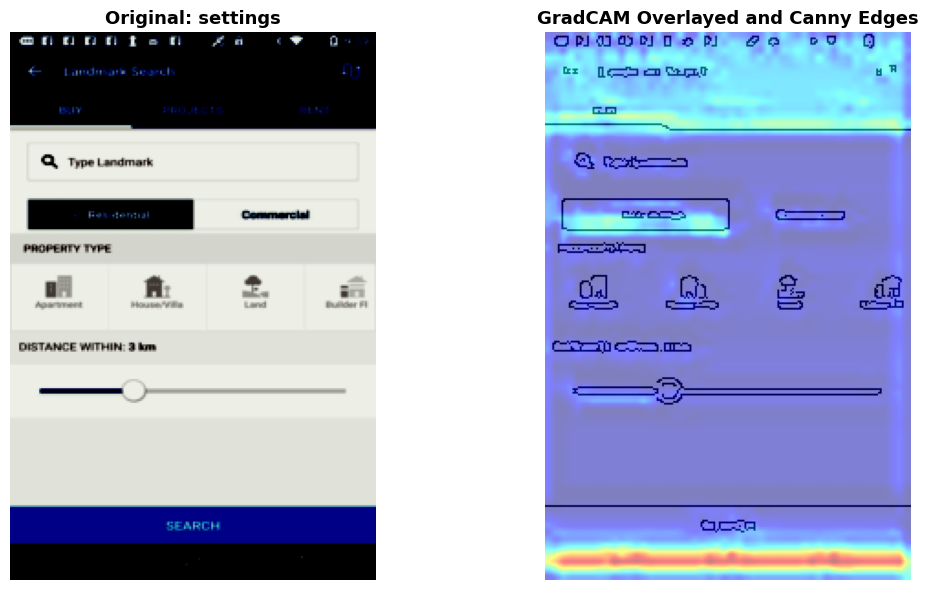

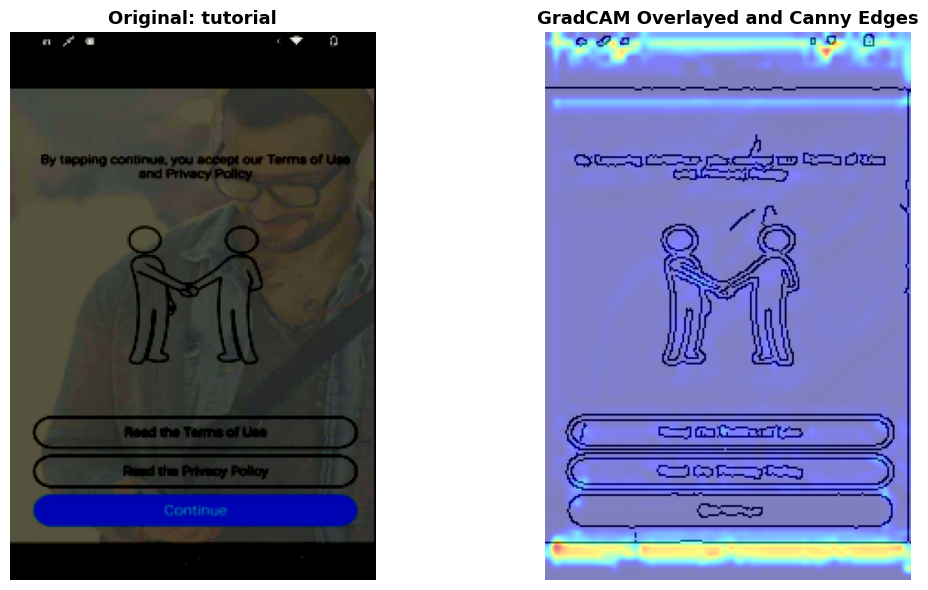

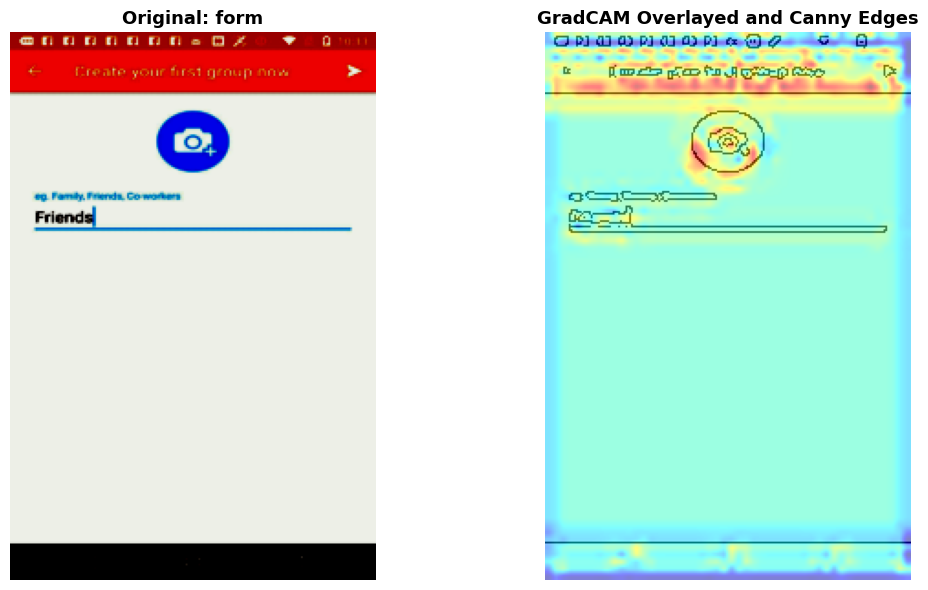

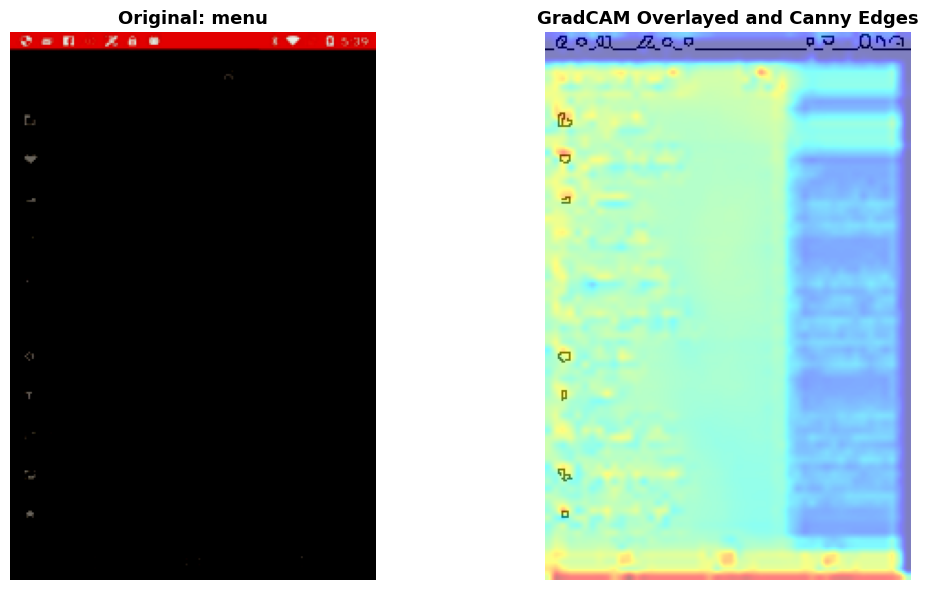

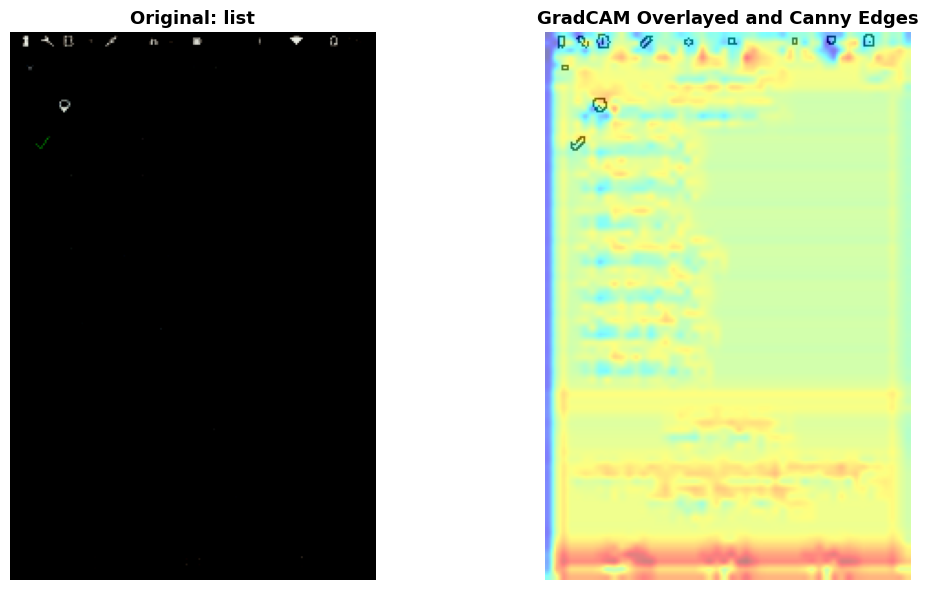

In [29]:
plot_random_gradcam_edges(
    model=model,
    target_layers=model.features[4].conv,  # Make sure to target the internal .conv layer!
    samples_dict=sps_enrico,         # Your dictionary of {target_idx: image_tensor}
    class_names=idx_to_class,             # Your mapping of index to class string
    num_samples=5,                         
    file_name="screen_image_4_layer"# How many random classes to plot
)

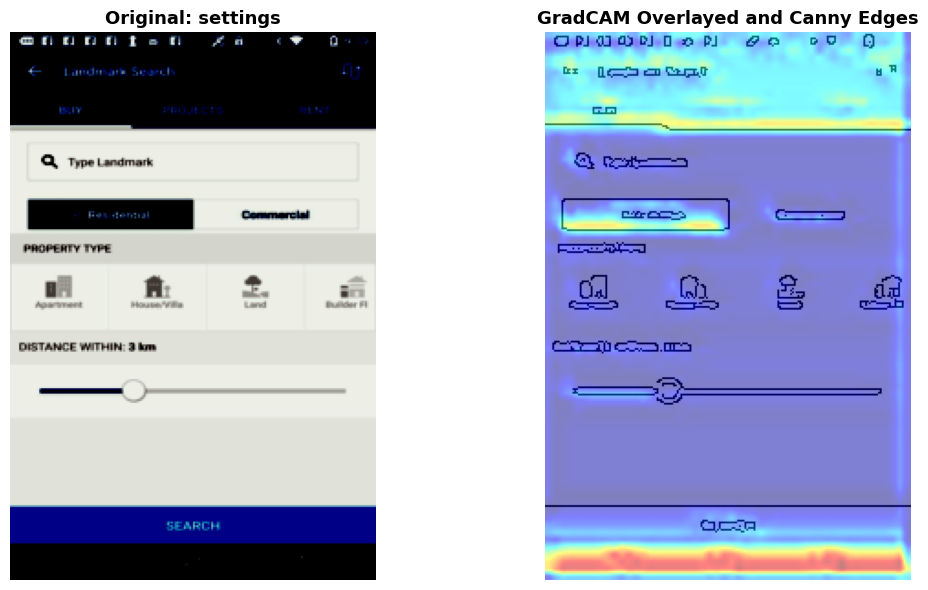

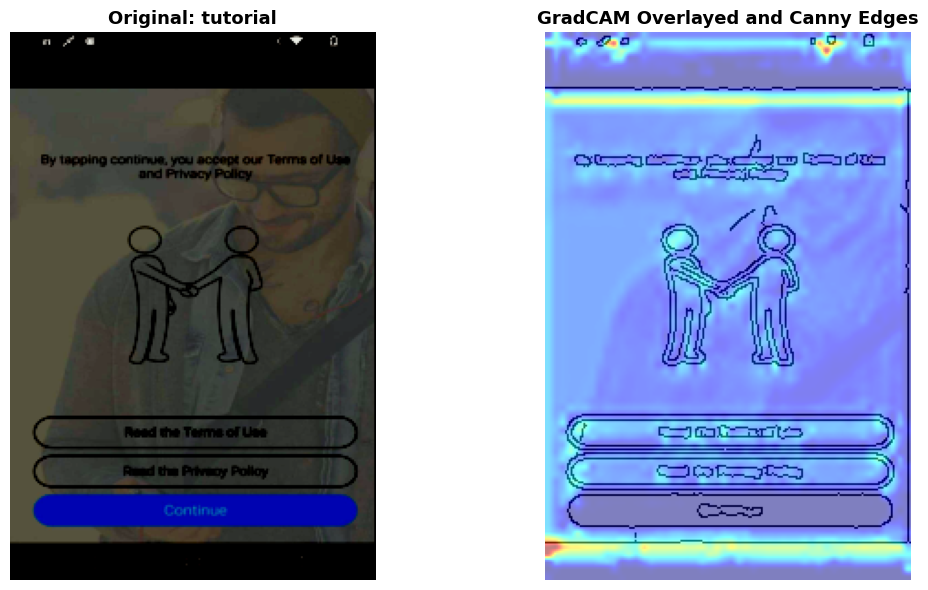

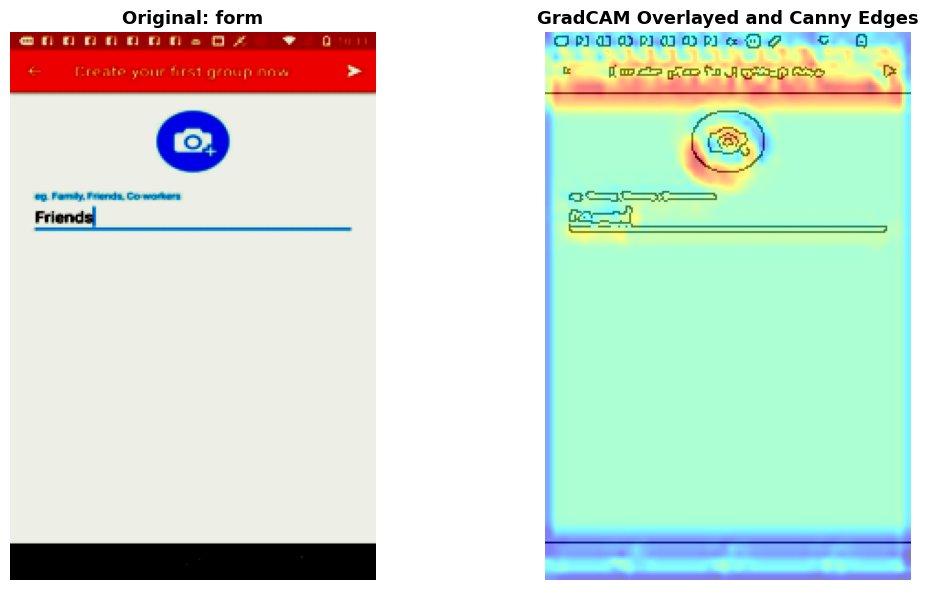

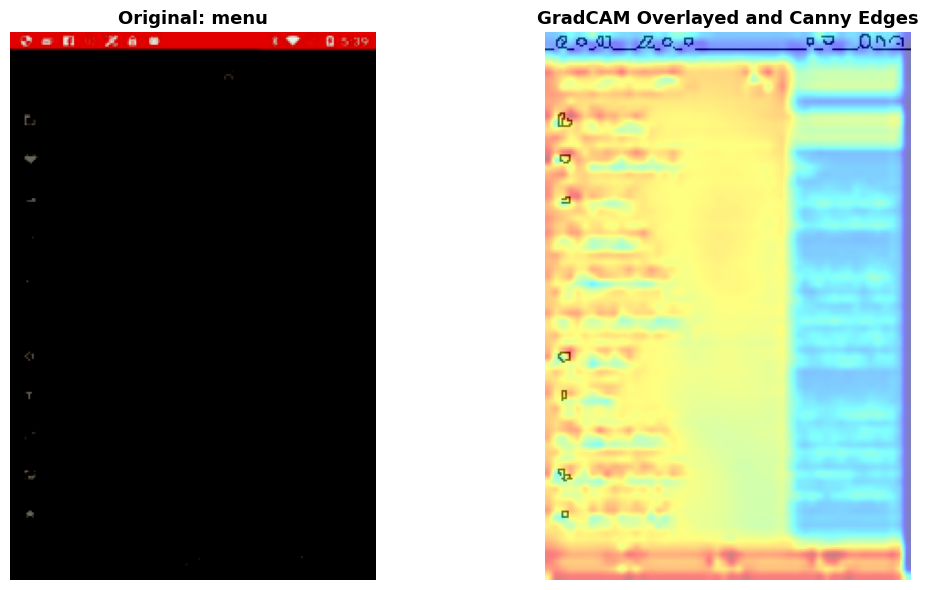

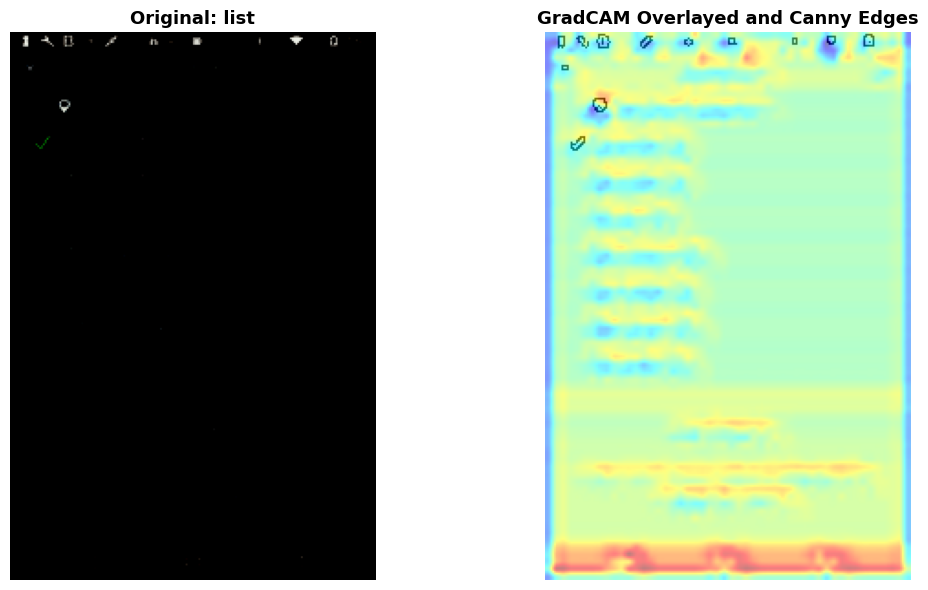

In [30]:
plot_random_gradcam_edges(
    model=model,
    target_layers=[model.features[x].conv for x in range(3,5)],  # Make sure to target the internal .conv layer!
    samples_dict=sps_enrico,         # Your dictionary of {target_idx: image_tensor}
    class_names=idx_to_class,             # Your mapping of index to class string
    num_samples=5,                         
    file_name="screen_image_3_and_4_layer"
)

# Analying the internal representation drift using CKA and PWCCA(https://arxiv.org/pdf/1905.00414 and https://arxiv.org/abs/1806.05759)

## CKA
### Step 1: Environment Setup
First, we install the open-source `torch_cka` library. This library automatically handles the forward hooks, feature extraction, and matrix math required to generate a complete layer-by-layer similarity heatmap.

In [31]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Subset, TensorDataset
from torchvision import datasets
from torchvision.transforms import v2
from torch_cka import CKA


### Step 2: Handling the Resolution Mismatch
Because the baseline model was trained on **300x200** images and the fine-tuned model expects **320x180** screen layouts, we cannot pass the exact same tensor to both. 

Instead, we will create **two separate DataLoaders** pointing to the exact same probe dataset, but applying their respective resizing transforms. `torch_cka` will pass `dataloader_natural` to Model 1 and `dataloader_screen` to Model 2, ensuring each model receives the resolution it is mathematically optimized for.

**Preparation of the Enrico dataset**

In [32]:
caltech_base_dataset = datasets.Caltech101(root="./data", download=True)
caltech_train_raw, _, _ = stratified_three_way_split(
    dataset=caltech_base_dataset,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1
)

caltech_preprocess = make_caltech_base_transform(resize=(300, 200))
caltech_train_raw_loader = torch.utils.data.DataLoader(
    AugmentationWrapper(caltech_train_raw, caltech_preprocess),
    batch_size=64,
    shuffle=False,
    num_workers=3
)
caltech_train_mean, caltech_train_std = mean_and_std_for_normalization(caltech_train_raw_loader)

universal_base_nat_images = v2.Compose([
    caltech_preprocess,
    v2.Normalize(mean=caltech_train_mean, std=caltech_train_std, inplace=False)
])

universal_base_screen = v2.Compose([
    screen_preprocess,
    v2.Normalize(mean=screen_train_mean, std=screen_train_std, inplace=False)
])

In [33]:
_, _, full_natural_test = CustomEnricoDataset.create_splits(
    root=ENRICO_ROOT,
    val_size=0.1,
    test_size=0.1,
    use_wireframes=False,
    train_transform=universal_base_nat_images,
    eval_transform=universal_base_nat_images
)

_, _, full_screen_test = CustomEnricoDataset.create_splits(
    root=ENRICO_ROOT,
    val_size=0.1,
    test_size=0.1,
    use_wireframes=False,
    train_transform=universal_base_screen,
    eval_transform=universal_base_screen
)

full_natural_test_loader = torch.utils.data.DataLoader(full_natural_test, batch_size=128, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test, batch_size=128, shuffle=False, pin_memory=True, num_workers=3)


### Step 3: Model Initialization and CKA Execution
Now we load the checkpoints. We will instantiate the CKA analyzer and pass both models to it. The `compare()` function will automatically loop through every single layer in both architectures and build a full grid of similarities.

> **Warning:** Depending on your model depth and batch size, this cell might take a few minutes to run.

In [34]:
last_three_convs = ["features.0.conv", "features.1.conv", "features.3.conv", "features.4.conv"]

model_baseline = PseudoAlexNet(tiny_factor=1, p=0).to(DEVICE)
load_checkpoint(model=model_baseline, optimizer=None, path=CHECKPOINTS_NAT_IMAGES_PATH, device=DEVICE)
model_baseline.classifier = nn.Identity()
model_baseline = model_baseline.to(DEVICE)

model_finetuned = PseudoAlexNet(tiny_factor=1, p=0).to(DEVICE)
reset_head_last_fc(model_finetuned, output_features=ENRICO_CLASSES)
load_checkpoint(model=model_finetuned, optimizer=None, path=CHECKPOINTS_FT_FINISHED_PATH, device=DEVICE)
model_finetuned.classifier = nn.Identity()
model_finetuned = model_finetuned.to(DEVICE)

model_screen = PseudoAlexNet(tiny_factor=1, p=0).to(DEVICE)
reset_head_last_fc(model_screen, output_features=ENRICO_CLASSES)
load_checkpoint(model=model_screen, optimizer=None, path=CHECKPOINTS_SCREEN_PATH, device=DEVICE)
model_screen.classifier = nn.Identity()
model_screen = model_screen.to(DEVICE)

model_untrained = PseudoAlexNet(tiny_factor=1, p=0).to(DEVICE)
model_untrained.classifier = nn.Identity()
model_untrained = model_untrained.to(DEVICE)

model_baseline.eval()
model_finetuned.eval()
model_screen.eval()
model_untrained.eval()

# Generates standard normal Gaussian noise matching (Channels, Height, Width) of domain
noise_tensors = torch.randn(256, 3, 300, 200)
dummy_labels = torch.zeros(256, dtype=torch.long)
noise_dataset = TensorDataset(noise_tensors, dummy_labels)
noise_loader = DataLoader(noise_dataset, batch_size=32, shuffle=False)

cka_baseline_ft = CKA(
    model1=model_baseline,
    model2=model_finetuned,
    model1_name="Baseline (Natural 300x200)",
    model2_name="Fine-tuned (Screen 300x200)",
    model1_layers=last_three_convs,
    model2_layers=last_three_convs,
    device=DEVICE.type
)

cka_baseline_screen = CKA(
    model1=model_baseline,
    model2=model_screen,
    model1_name="Baseline (Natural 300x200)",
    model2_name="Scratch (Screen 300x200)",
    model1_layers=last_three_convs,
    model2_layers=last_three_convs,
    device=DEVICE.type
)

cka_ft_screen = CKA(
    model1=model_finetuned,
    model2=model_screen,
    model1_name="Fine-tuned (Screen 300x200)",
    model2_name="Scratch (Screen 300x200)",
    model1_layers=last_three_convs,
    model2_layers=last_three_convs,
    device=DEVICE.type
)

cka_noise_baseline = CKA(
    model1=model_baseline,
    model2=model_finetuned,
    model1_name="Baseline (Noise Input)",
    model2_name="Fine-tuned (Noise Input)",
    model1_layers=last_three_convs,
    model2_layers=last_three_convs,
    device=DEVICE.type
)

cka_untrained_control = CKA(
    model1=model_baseline,
    model2=model_untrained,
    model1_name="Baseline (Natural 300x200)",
    model2_name="Untrained Initialization",
    model1_layers=last_three_convs,
    model2_layers=last_three_convs,
    device=DEVICE.type
)

print("Starting CKA computation across all layers...")

print("\n--- 1. Experimental Comparisons ---")
print("Computing Baseline vs Fine-tuned...")
cka_baseline_ft.compare(dataloader1=full_natural_test_loader, dataloader2=full_screen_test_loader)

print("Computing Baseline vs Scratch...")
cka_baseline_screen.compare(dataloader1=full_natural_test_loader, dataloader2=full_screen_test_loader)

print("Computing Fine-tuned vs Scratch...")
cka_ft_screen.compare(dataloader1=full_screen_test_loader, dataloader2=full_screen_test_loader)

print("\n--- 2. Scientific Baselines (Null Hypotheses) ---")
print("Computing Architectural Floor (Gaussian Noise)...")
cka_noise_baseline.compare(dataloader1=noise_loader, dataloader2=noise_loader)

print("Computing Initialization Floor (Untrained Weights)...")
cka_untrained_control.compare(dataloader1=full_natural_test_loader, dataloader2=full_screen_test_loader)

print("\nCKA computation complete!")


⚠️ Path not found: /kaggle/input/20-checkpoint-batchnorm/finished_nat_images_max_epochs.pth
⚠️ Path not found: /kaggle/input/20-checkpoint-batchnorm/finished_drift_2_max_epochs.pth
⚠️ Path not found: /kaggle/input/20-checkpoint-batchnorm/finished_screen_max_epochs.pth
Starting CKA computation across all layers...

--- 1. Experimental Comparisons ---
Computing Baseline vs Fine-tuned...


| Comparing features |: 100%|██████████| 1/1 [00:03<00:00,  3.59s/it]

Computing Baseline vs Scratch...



| Comparing features |: 100%|██████████| 1/1 [00:02<00:00,  2.58s/it]

Computing Fine-tuned vs Scratch...


...


--- 2. Scientific Baselines (Null Hypotheses) ---
Computing Architectural Floor (Gaussian Noise)...


| Comparing features |: 100%|██████████| 8/8 [00:00<00:00, 17.46it/s]

Computing Initialization Floor (Untrained Weights)...



| Comparing features |: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]


CKA computation complete!


Providing CKA results

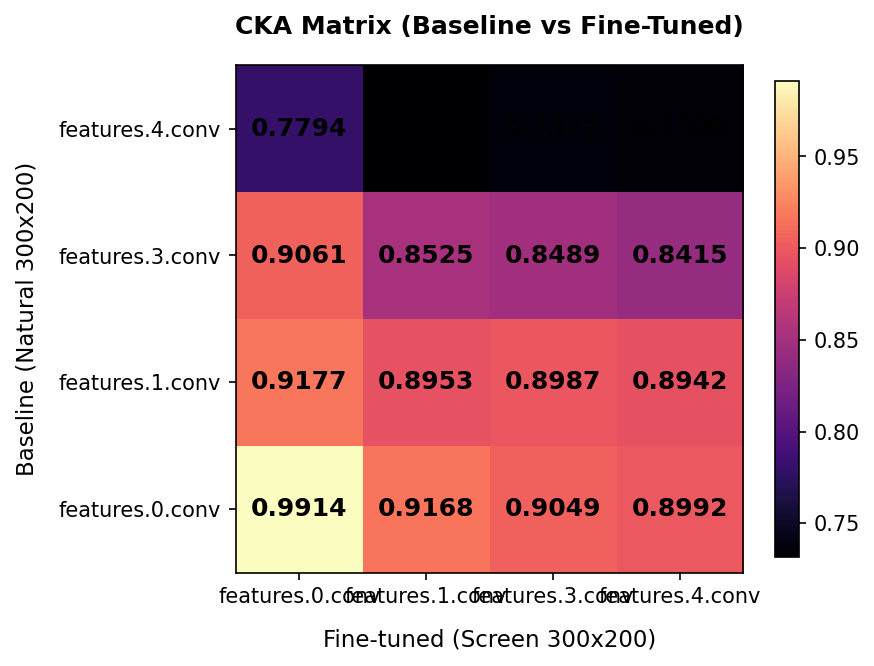

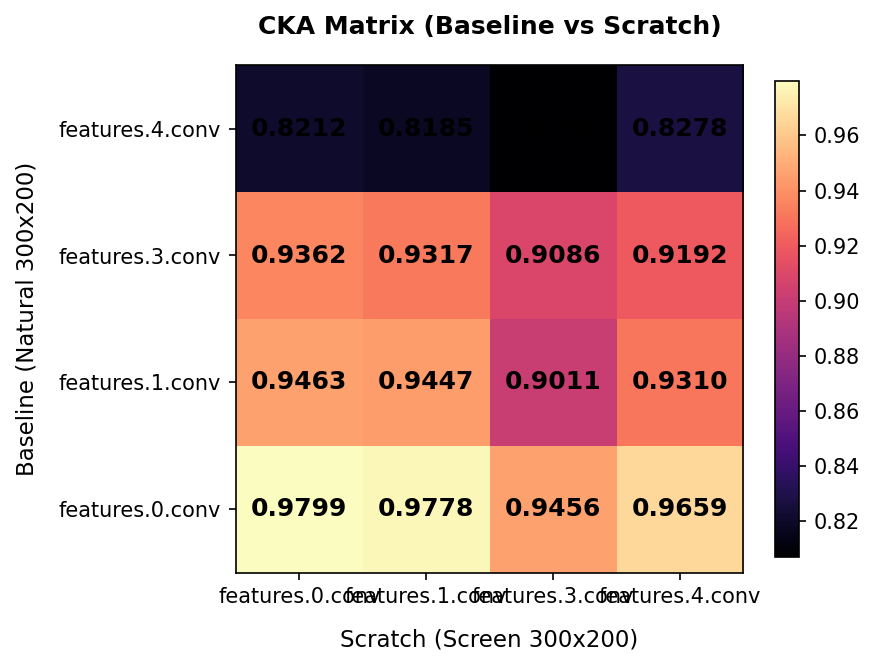

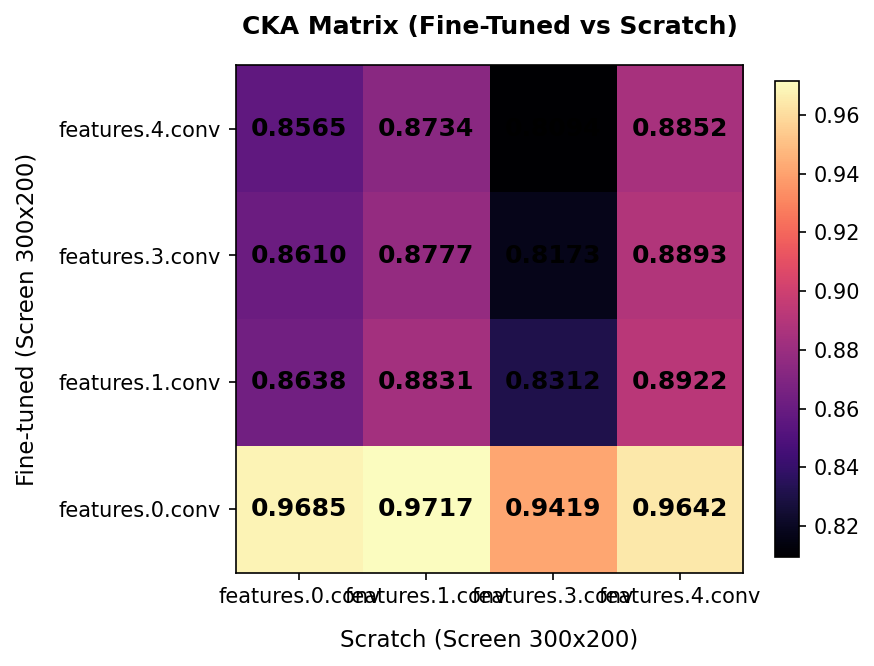

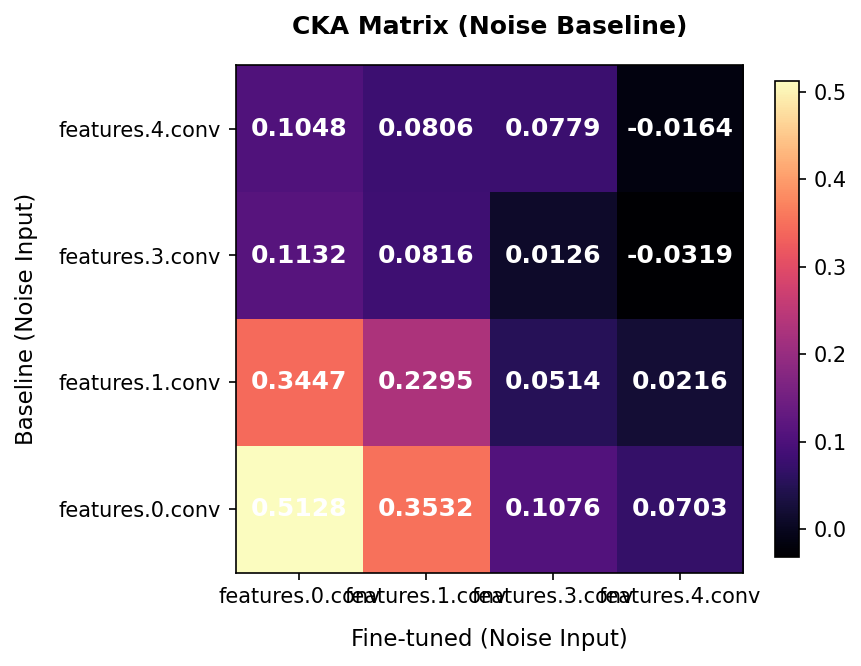

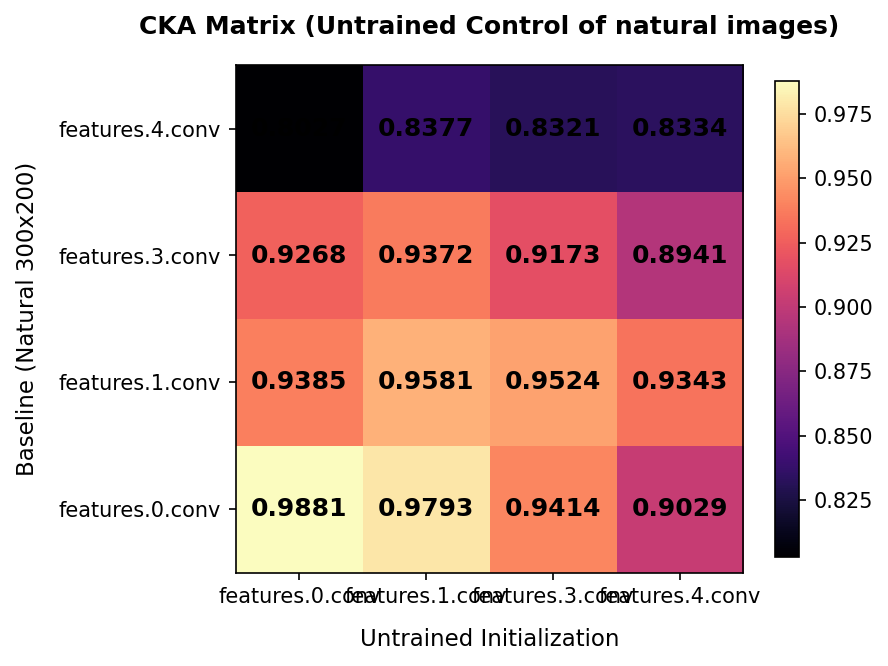

In [35]:
plot_all_cka_pairs(
    cka_bf=cka_baseline_ft,
    cka_bs=cka_baseline_screen,
    cka_fs=cka_ft_screen,
    cka_nb=cka_noise_baseline,
    cka_uc=cka_untrained_control
)

## Sparsity check

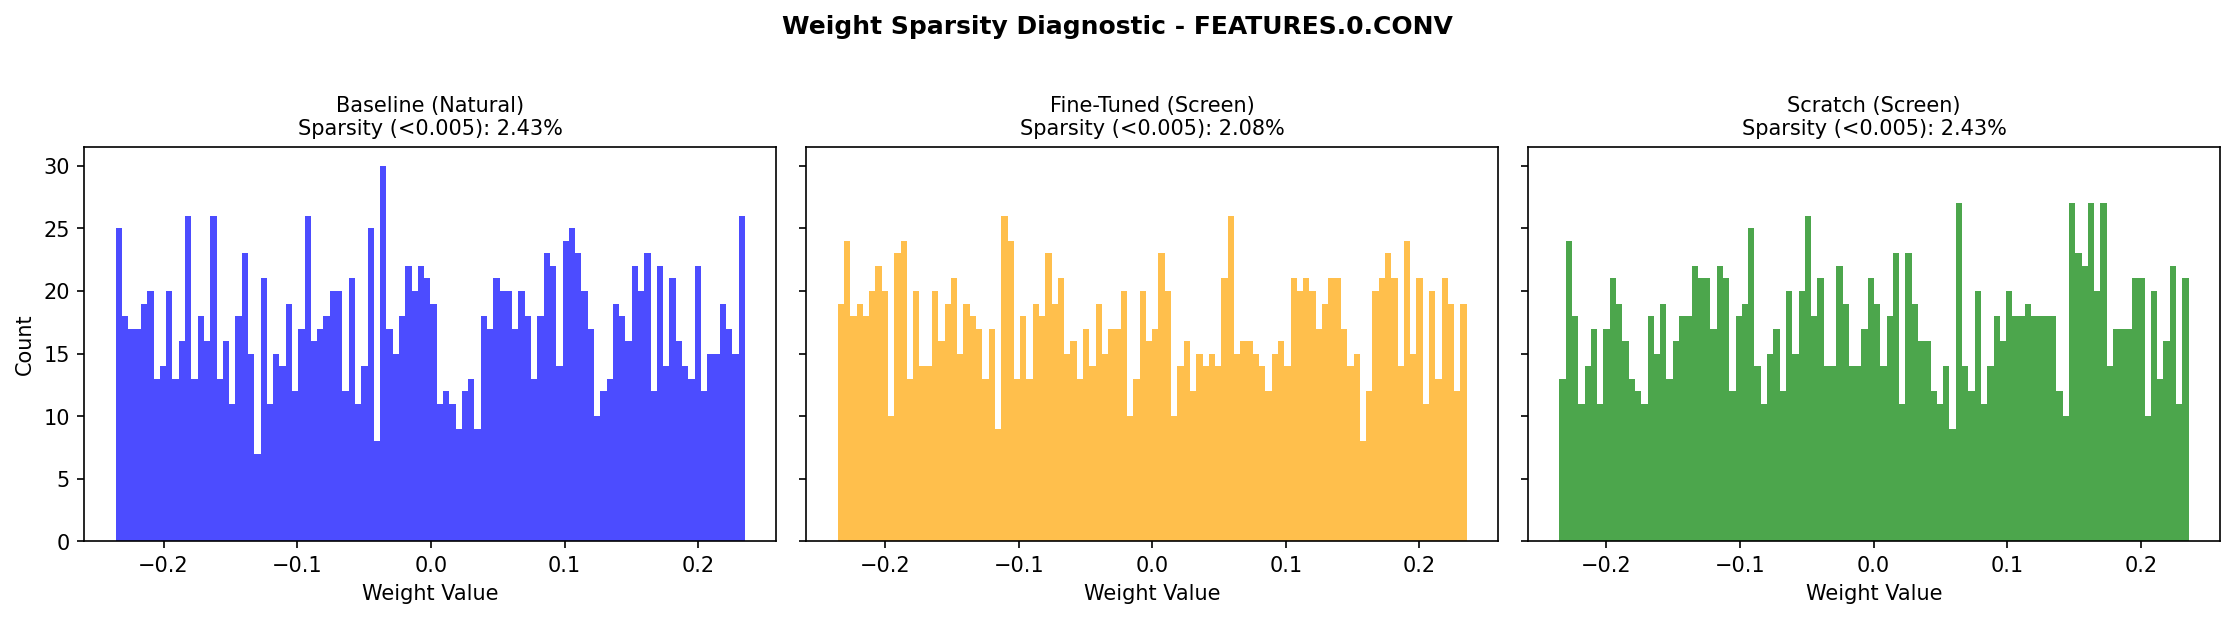

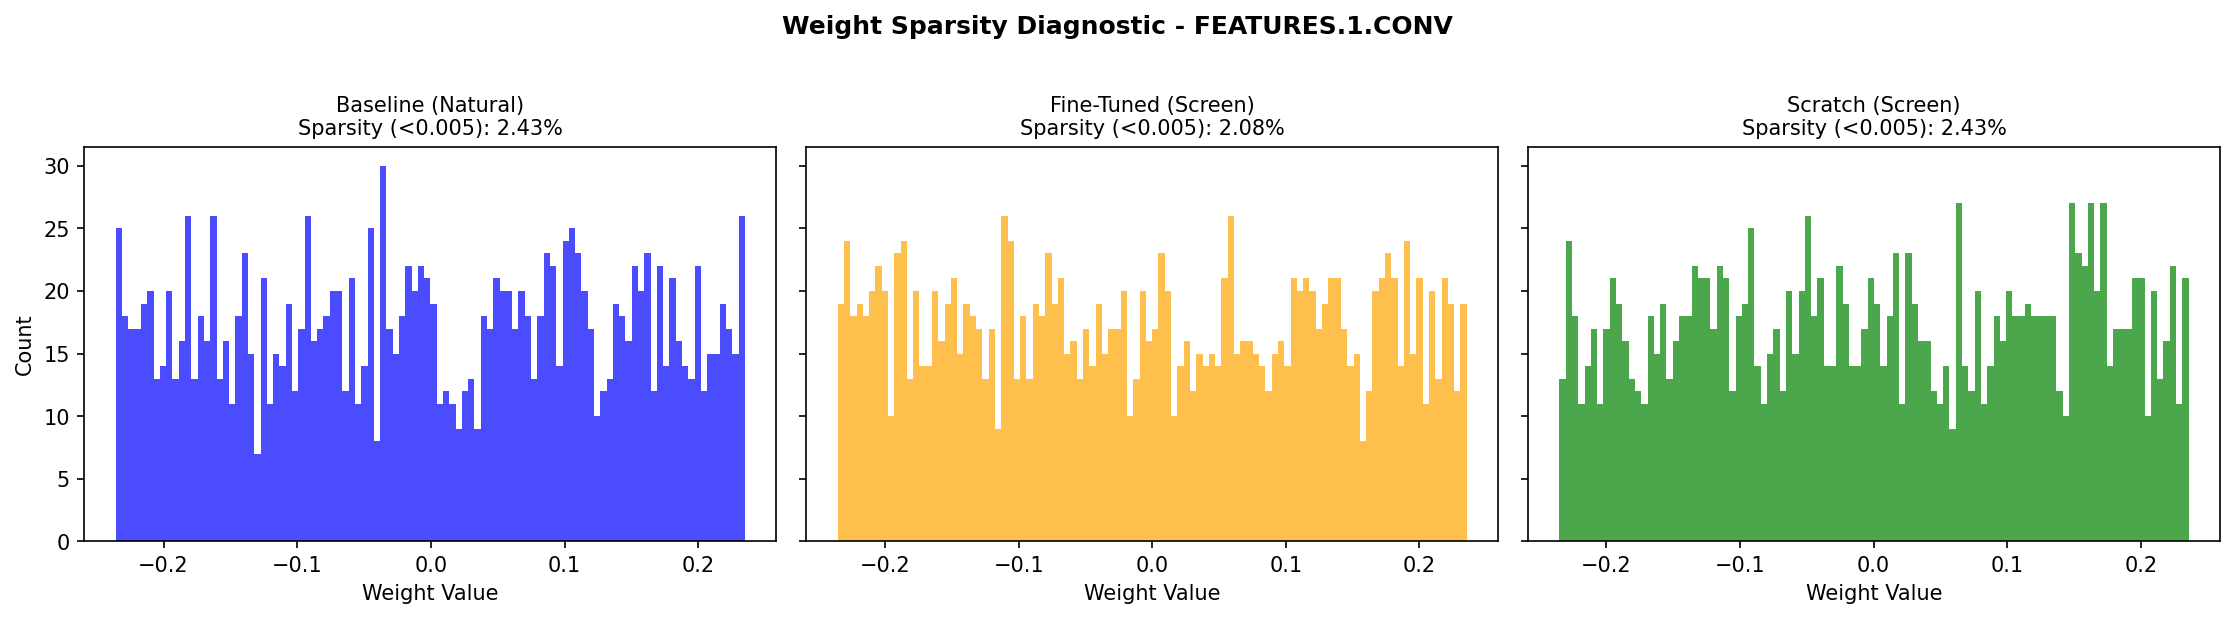

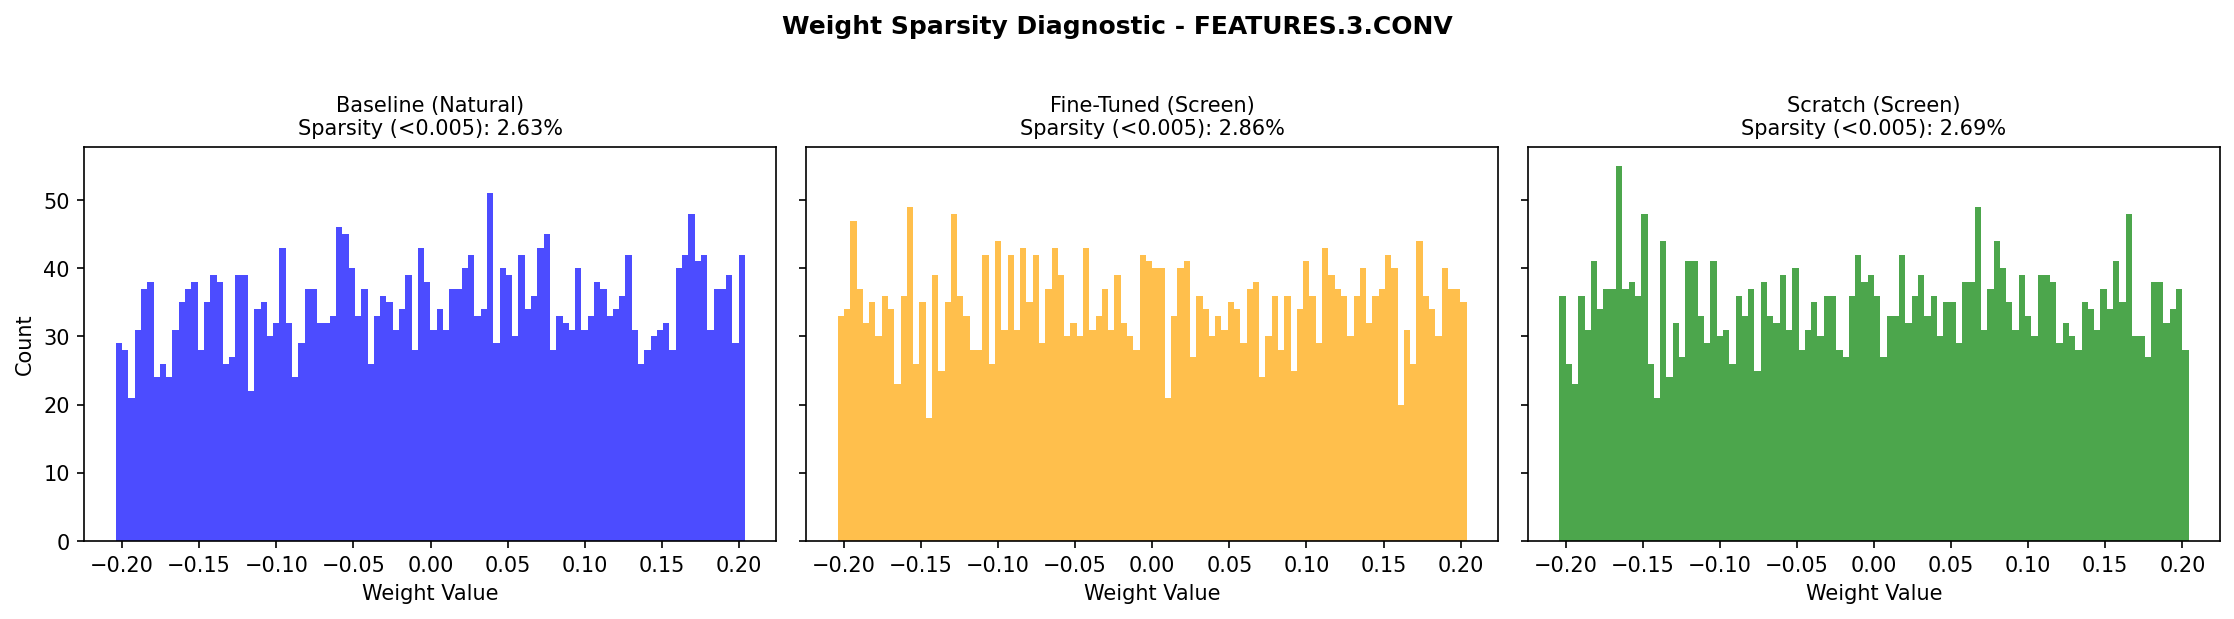

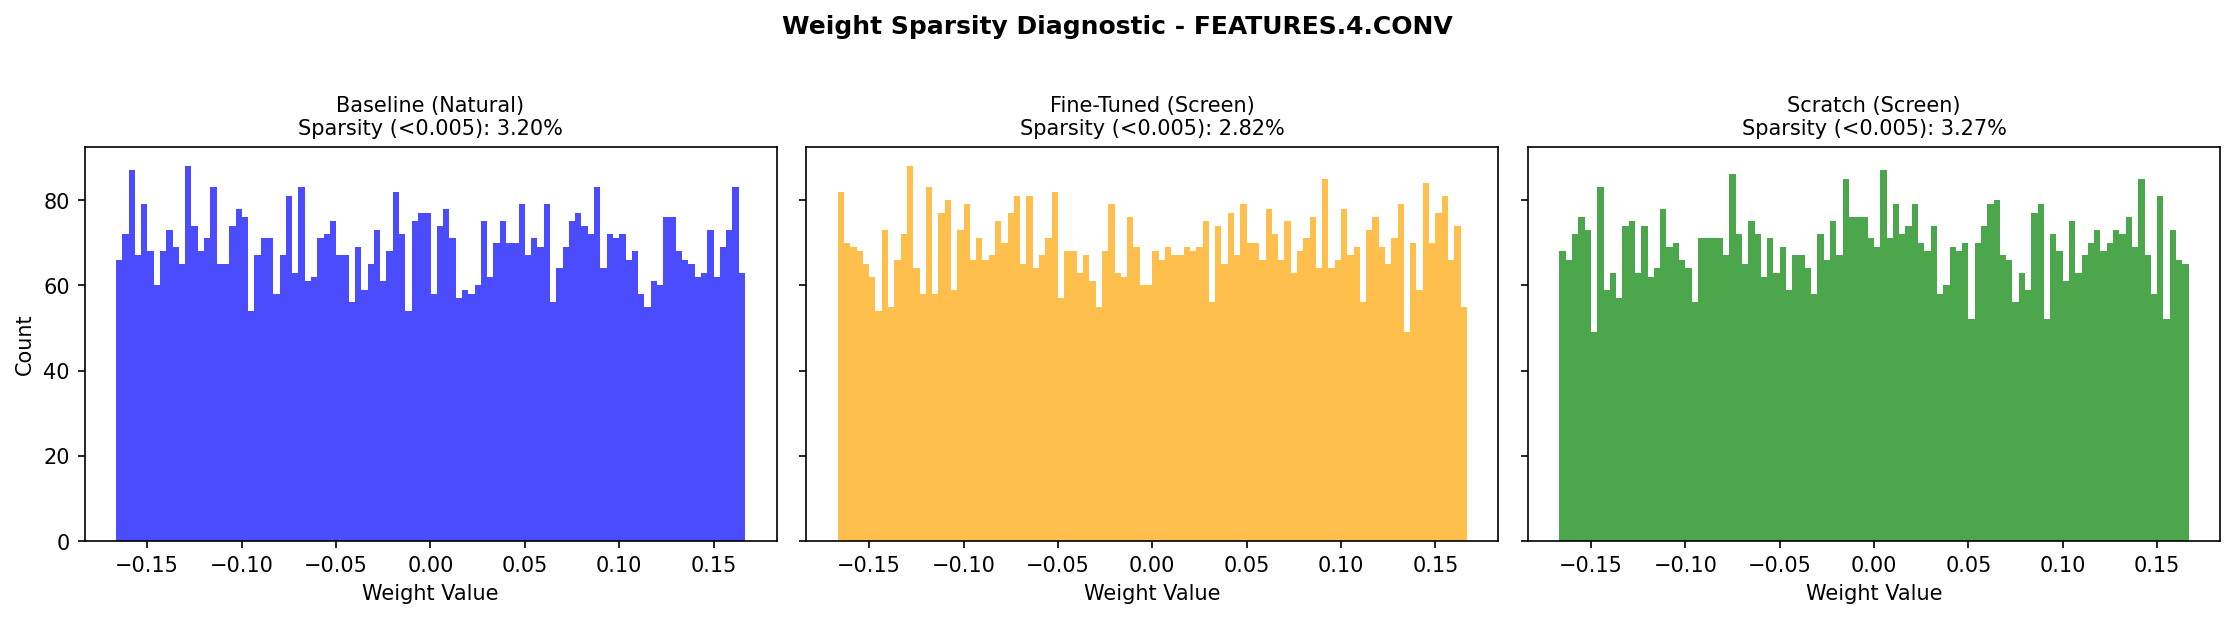

In [36]:
models_list = [model_baseline, model_finetuned, model_screen]
names_list = ["Baseline (Natural)", "Fine-Tuned (Screen)", "Scratch (Screen)"]

threshold = 0.005
plot_layer_weight_diagnostic(models_list, names_list, layer_num=1, layer_name="features.0.conv", threshold=threshold)
plot_layer_weight_diagnostic(models_list, names_list, layer_num=1, layer_name="features.1.conv", threshold=threshold)
plot_layer_weight_diagnostic(models_list, names_list, layer_num=3, layer_name="features.3.conv", threshold=threshold)
plot_layer_weight_diagnostic(models_list, names_list, layer_num=4, layer_name="features.4.conv", threshold=threshold)